<a href="https://colab.research.google.com/github/wahyunirosyidah/Klasifikasi-Jenis-Jenis-Noken-Menggunakan-CNN/blob/main/(TF)Klasifikasi_Jenis_Jenis_Noken_Menggunakan_CNN_Berdasarkan_Suku.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom, RandomContrast, RandomTranslation,
    Dense, Flatten, Dropout
)
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet, MobileNetV2
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm as colormap
from ipywidgets import widgets
from IPython.display import display
from io import BytesIO


In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd '/content/drive/MyDrive/SKRIPSI AYU'

Mounted at /content/drive
/content/drive/MyDrive/SKRIPSI AYU


In [3]:
# Directory Path
BASE_DIR = 'Dataset per Suku'
print(f"Base Directory: {os.listdir(BASE_DIR)}")

data_train=f'{BASE_DIR}/train'
print(f"Train Directory: {sorted(os.listdir(data_train))}")
data_validation=f'{BASE_DIR}/valid'
print(f"Valid Directory: {sorted(os.listdir(data_validation))}")
data_test=f'{BASE_DIR}/test'
print(f"Test Directory: {sorted(os.listdir(data_test))}")

Base Directory: ['valid', 'test', 'train']
Train Directory: ['Mee', 'Sentani']
Valid Directory: ['Mee', 'Sentani']
Test Directory: ['Mee', 'Sentani']


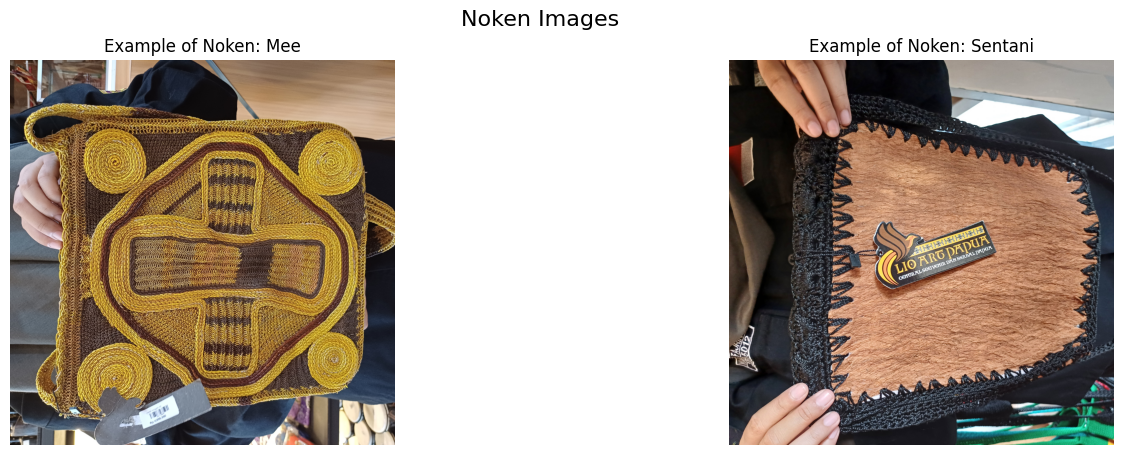

In [4]:
# Plot noken Images
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle('Noken Images', fontsize=16)

# List of noken
noken_list = os.listdir(data_train)
# Plot images for each noken
for i, noken in enumerate(noken_list):
    dir_path = f'{data_train}/{noken}'
    img = tf.keras.preprocessing.image.load_img(dir_path + '/' + os.listdir(dir_path)[0])
    # row, col = divmod(i, 3)
    axes[i].imshow(img)
    axes[i].set_title(f'Example of Noken: {noken}')
    axes[i].axis('off')

# Disable axis on empty subplots if any
for jj in range(len(noken_list), 9):
    row, col = divmod(jj, 3)
    axes[i].axis('off')

plt.show()

In [5]:
BATCH_SIZE=32

In [6]:
train_datagen = ImageDataGenerator(
                    rescale=1/255,
                                     rotation_range=10,
                                     width_shift_range=0.2,
                                     height_shift_range=0.2,
                                     shear_range=0.2,
                                     zoom_range=0.2,
                                     horizontal_flip=True,
                                     vertical_flip=True,
                                     fill_mode='reflect')

valid_datagen = ImageDataGenerator(
                    rescale=1./255)

test_datagen = ImageDataGenerator(
                    rescale=1./255)

In [7]:
train_generator = train_datagen.flow_from_directory(
        data_train,
        target_size=(224, 224),
        batch_size=BATCH_SIZE,
        class_mode='binary')

validation_generator = valid_datagen.flow_from_directory(
        data_validation,
        target_size=(224, 224),
        batch_size=BATCH_SIZE,
        class_mode='binary')

test_generator = test_datagen.flow_from_directory(
        data_test,
        target_size=(224, 224),
        batch_size=BATCH_SIZE,
        shuffle=False)

Found 346 images belonging to 2 classes.
Found 78 images belonging to 2 classes.
Found 78 images belonging to 2 classes.


In [8]:
based_model = MobileNetV2(input_shape=(224,224,3), include_top=False)

for layer in based_model.layers:
  layer.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
def model_to_use():
    model = tf.keras.models.Sequential([
        based_model,
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    return model

In [11]:
model = model_to_use()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 62720)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       8,028,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,286,913 (39.24 MB)

 Trainable params: 8,028,673 (30.63 MB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [12]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.optimizers.Adam(),
              metrics=['accuracy'])

In [13]:
epoch = 15
history = model.fit(train_generator,
                    batch_size=BATCH_SIZE,
                    epochs=epoch,
                    validation_data=validation_generator,
                    shuffle=True)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 140s 12s/step - accuracy: 0.8103 - loss: 0.4488 - val_accuracy: 0.9744 - val_loss: 0.1105
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.9640 - loss: 0.0638 - val_accuracy: 0.9744 - val_loss: 0.0589
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.9862 - loss: 0.0460 - val_accuracy: 0.9744 - val_loss: 0.0694
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.9746 - loss: 0.0742 - val_accuracy: 0.9744 - val_loss: 0.0670
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9986 - loss: 0.0223 - val_accuracy: 0.9744 - val_loss: 0.0466
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.9957 - loss: 0.0202 - val_accuracy: 0.9744 - val_loss: 0.0420
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.9968 - loss: 0.0142 - val_accuracy: 0.9744 - val_loss: 0.0414
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.9964 - loss: 0.0160 - val_accuracy: 0.9872 - val_los

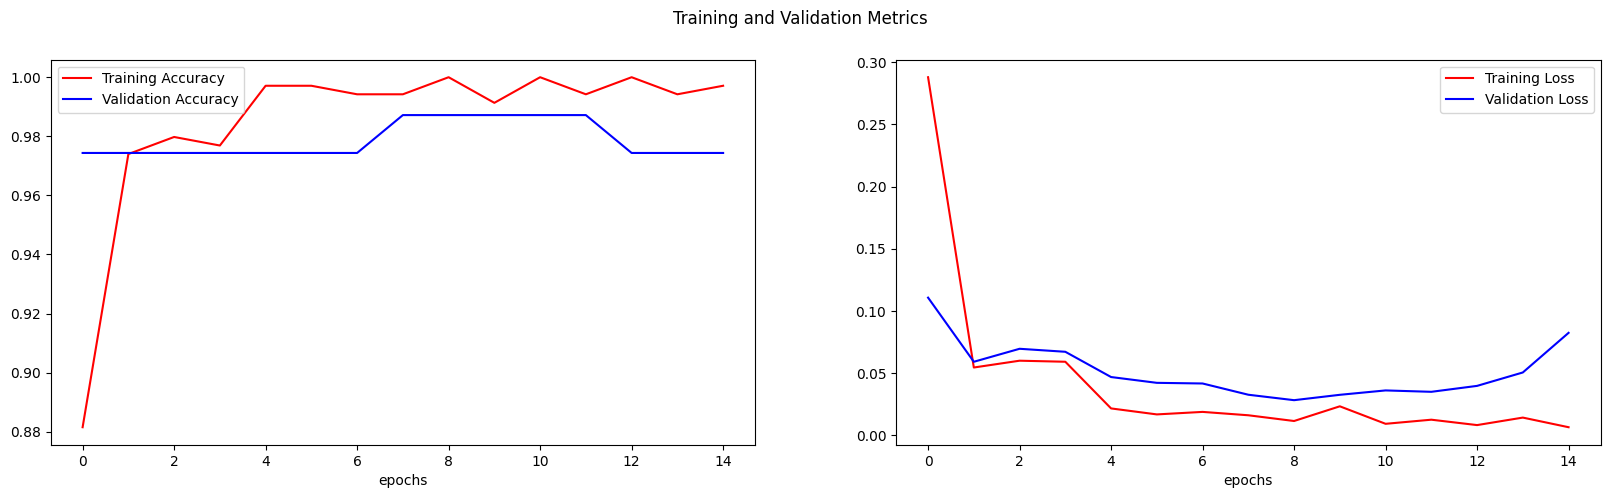

In [14]:
# Plot training and validation accuracy & loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

fig, ax = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle('Training and Validation Metrics')

for i, (data, label) in enumerate(zip([(acc, val_acc), (loss, val_loss)], ["Accuracy", "Loss"])):
    ax[i].plot(epochs, data[0], 'r', label="Training " + label)
    ax[i].plot(epochs, data[1], 'b', label="Validation " + label)
    ax[i].legend()
    ax[i].set_xlabel('epochs')

plt.show()

In [15]:
num_test_files = sum([len(files) for r, d, files in os.walk(data_test)])
num_test_steps = num_test_files // 32


acc = model.evaluate(test_generator, batch_size=BATCH_SIZE, verbose=1, steps=num_test_steps)[1] * 100
print(f"Accuracy on the test set is {acc:.2f} %")

ValueError: Cannot take the length of shape with unknown rank.

In [ ]:
predictions = model.predict(test_generator, verbose=1)

y_true = test_generator.classes
y_pred = np.argmax(predictions, axis=1)

conf_matrix = confusion_matrix(y_true, y_pred)
errors_per_class = conf_matrix.sum(axis=1) - np.diag(conf_matrix)

class_labels = list(test_generator.class_indices.keys())

filtered_labels = [label for label, errors in zip(class_labels, errors_per_class) if errors > 0]
filtered_errors = [errors for errors in errors_per_class if errors > 0]

colors = colormap.get_cmap('tab10', len(filtered_labels)).colors

plt.figure(figsize=(8, len(filtered_labels) * 0.6))
plt.barh(filtered_labels, filtered_errors, color=colors)
plt.title('Errors by Class on Test Set', fontsize=12)
plt.xlabel('Number of Errors', fontsize=10)
plt.ylabel('Class Labels', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()



In [ ]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

Classification Report:
                      precision    recall  f1-score   support

             Anggrek       0.97      1.00      0.99        39
Kulit Kayu Non Rajut       1.00      0.97      0.99        39
               Rajut       1.00      1.00      1.00        39

            accuracy                           0.99       117
           macro avg       0.99      0.99      0.99       117
        weighted avg       0.99      0.99      0.99       117



In [ ]:
def process_image(image_path, target_size=(224, 224)):

    image = load_img(image_path, target_size=target_size)
    image_array = img_to_array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)
    return image_array

def predict_image(model, file_content, class_labels):

    image = load_img(BytesIO(file_content), target_size=(224, 224))
    processed_image = img_to_array(image) / 255.0
    processed_image = np.expand_dims(processed_image, axis=0)

    prediction = model.predict(processed_image)[0]
    predicted_class = np.argmax(prediction)

    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted: {class_labels[predicted_class]} (Confidence: {prediction[predicted_class]*100:.2f}%)")
    plt.show()

    print("Prediction Probabilities:")
    for i, prob in enumerate(prediction):
        print(f"{class_labels[i]}: {prob*100:.2f}%")

uploader = widgets.FileUpload(accept="image/*", multiple=False)
display(uploader)

output = widgets.Output()
display(output)

def on_file_upload(change):
    with output:
        output.clear_output()
        for filename, file_info in uploader.value.items():
            file_content = file_info["content"]
            print(f"Processing file: {filename}")
            #Predict Image
            predict_image(model_to_use, file_content, class_labels)

class_labels = list(test_generator.class_indices.keys())

model_to_use = model

uploader.observe(on_file_upload, names="value")


FileUpload(value={}, accept='image/*', description='Upload')

Output()